<a href="https://colab.research.google.com/github/Thirupathi1356/CV-Final-Project-/blob/main/CV_Project1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics --quiet
!pip install opencv-python --quiet
!pip install gTTS --quiet
!pip install face_recognition --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
from gtts import gTTS
from IPython.display import Audio, display, Image
import os

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

import face_recognition

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO("yolov8n.pt")
print("✅ YOLO Model loaded successfully!")

✅ YOLO Model loaded successfully!


👥 Enter number of people/images: 2

📤 Upload image 1


Saving thirupathi.jpeg to thirupathi (2).jpeg
📷 Processing: thirupathi (2).jpeg


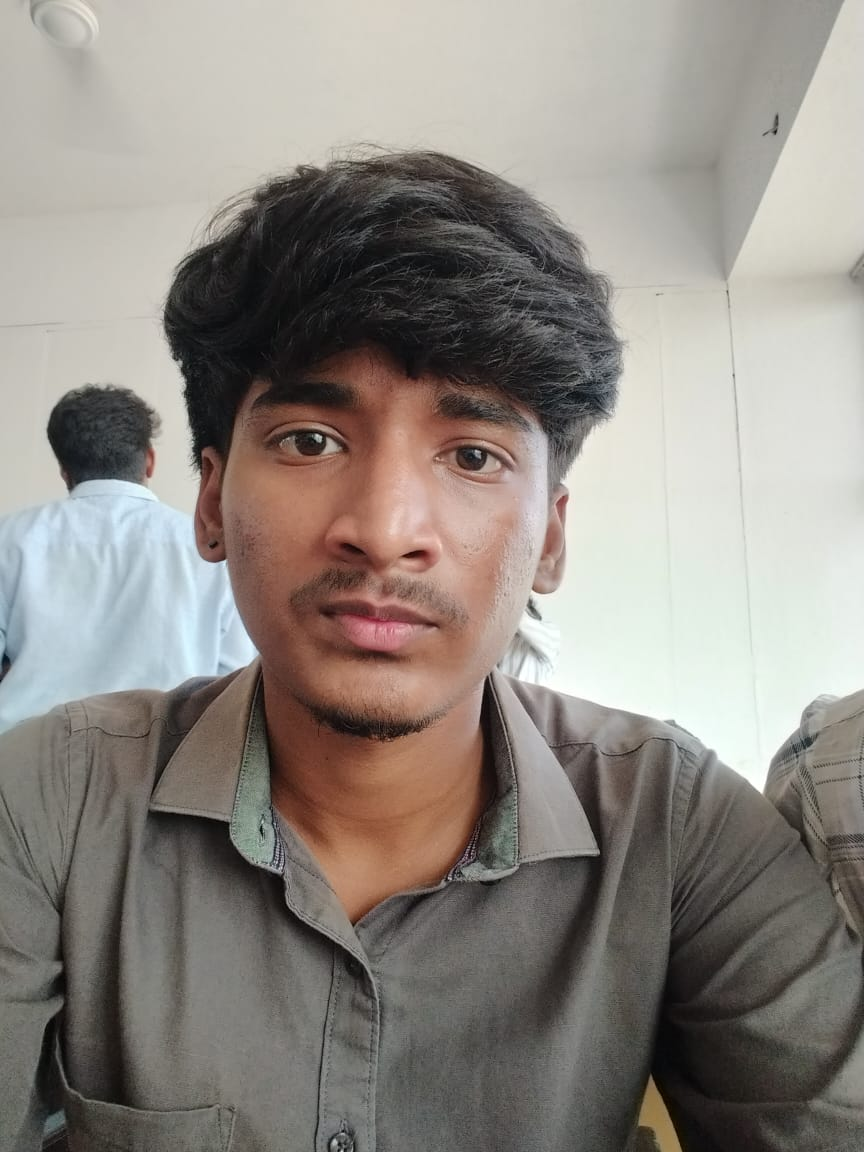

🧑 Enter person name: thirupathi
✅ Added: thirupathi

📤 Upload image 2


Saving WhatsApp Image 2026-04-09 at 10.05.26 (1).jpeg to WhatsApp Image 2026-04-09 at 10.05.26 (1) (1).jpeg
📷 Processing: WhatsApp Image 2026-04-09 at 10.05.26 (1) (1).jpeg


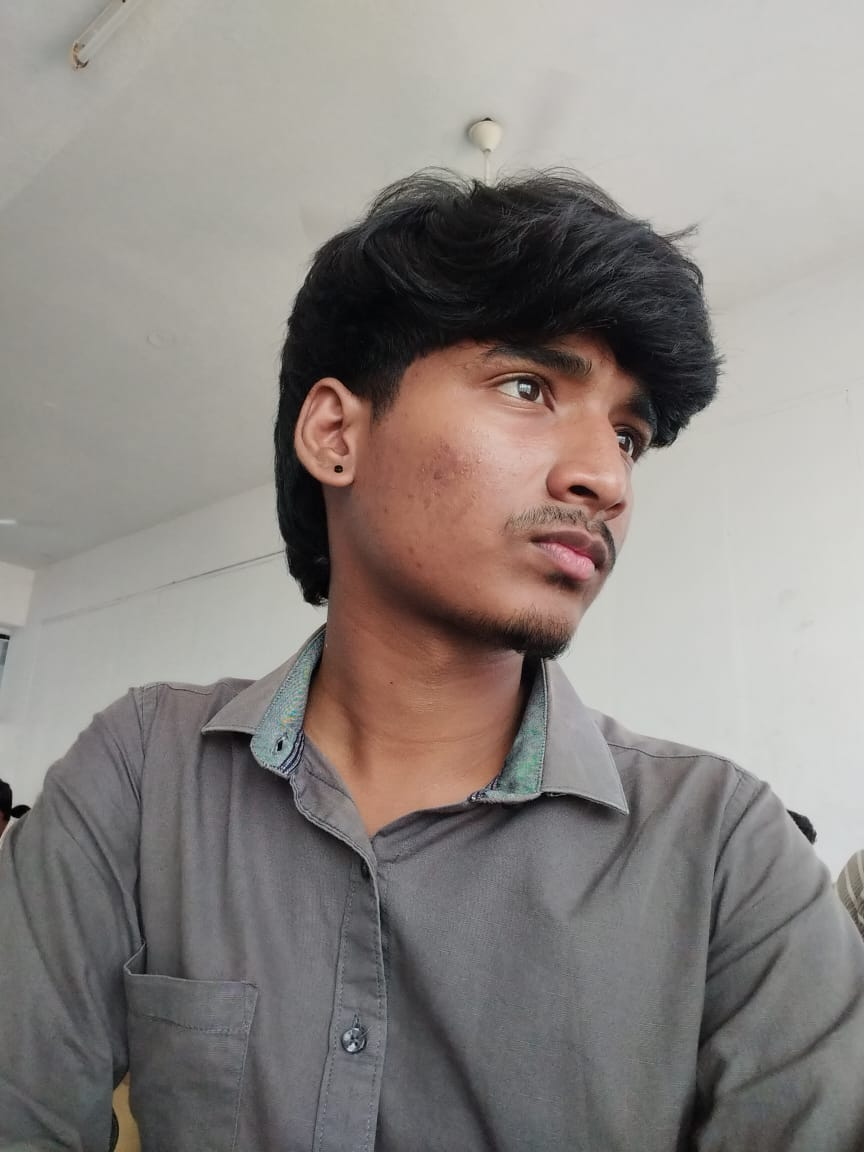

🧑 Enter person name: thirupathi
✅ Added: thirupathi

🎯 Final Faces Loaded: ['thirupathi', 'thirupathi']


In [4]:
from google.colab import files
from IPython.display import Image
import face_recognition

known_face_encodings = []
known_face_names = []

# 🔁 Repeat for multiple people
num_people = int(input("👥 Enter number of people/images: "))

for i in range(num_people):
    print(f"\n📤 Upload image {i+1}")

    uploaded = files.upload()  # file picker

    for filename in uploaded.keys():
        print(f"📷 Processing: {filename}")
        display(Image(filename))

        name = input("🧑 Enter person name: ")

        # Load image
        image = face_recognition.load_image_file(filename)
        face_locations = face_recognition.face_locations(image)

        if len(face_locations) == 0:
            print("❌ No face detected! Try another image.")
            continue

        # Encode face
        encodings = face_recognition.face_encodings(image, face_locations)

        if len(encodings) > 0:
            known_face_encodings.append(encodings[0])
            known_face_names.append(name)
            print(f"✅ Added: {name}")
        else:
            print("❌ Encoding failed!")

print("\n🎯 Final Faces Loaded:", known_face_names)

In [5]:
def speak(text):
    print("🔊 Voice:", text)
    tts = gTTS(text=text, lang='en')
    tts.save("voice.mp3")
    display(Audio("voice.mp3", autoplay=True))

In [6]:
def capture_image(delay=5):
    js = Javascript(f'''
    async function takePhoto() {{
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({{video: true}});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;

      await video.play();
      await new Promise(resolve => setTimeout(resolve, {delay*1000}));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }}
    ''')

    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    with open('image.jpg', 'wb') as f:
        f.write(binary)

    return 'image.jpg'

In [7]:
KNOWN_WIDTHS = {
    "person": 40,
    "car": 180,
    "bicycle": 60,
    "motorcycle": 80,
    "chair": 50
}

FOCAL_LENGTH = 700

In [8]:
def detect_and_guide(image_path):
    img = cv2.imread(image_path)
    results = model(img)
    result = results[0]

    h, w, _ = img.shape

    left_blocked = False
    center_blocked = False
    right_blocked = False

    obstacle_info = []

    # =========================
    # 👁️ FACE RECOGNITION
    # =========================
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face_locations = face_recognition.face_locations(rgb_img)
    face_encodings = face_recognition.face_encodings(rgb_img, face_locations)

    recognized_people = []

    for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

        matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
        name = "Unknown"

        face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)

        if len(face_distances) > 0:
            best_match_index = np.argmin(face_distances)
            if matches[best_match_index]:
                name = known_face_names[best_match_index]

        recognized_people.append(name)

        # Draw face box
        cv2.rectangle(img, (left, top), (right, bottom), (255, 0, 0), 2)
        cv2.putText(img, name, (left, top-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                    (255, 0, 0), 2)

    # =========================
    # 🤖 YOLO OBJECT DETECTION
    # =========================
    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]

        xmin, ymin, xmax, ymax = map(int, box.xyxy[0])
        center = (xmin + xmax) // 2
        box_width = xmax - xmin

        # Distance calculation
        if label in KNOWN_WIDTHS:
            real_width = KNOWN_WIDTHS[label]
            distance_cm = (real_width * FOCAL_LENGTH) / box_width

            if distance_cm < 100:
                distance_text = f"{round(distance_cm)} cm (very close)"
            elif distance_cm < 300:
                distance_text = f"{round(distance_cm/100,2)} m (near)"
            else:
                distance_text = f"{round(distance_cm/100,2)} m (far)"
        else:
            distance_cm = 999
            distance_text = "unknown"

        # Path blocking logic
        if distance_cm < 300:
            if center < w/3:
                left_blocked = True
            elif center < 2*w/3:
                center_blocked = True
            else:
                right_blocked = True

            obstacle_info.append(f"{label} ahead")

        # Draw object box
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0,255,0), 2)
        cv2.putText(img, f"{label} - {distance_text}",
                    (xmin, ymin-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (0,255,0), 2)

    # =========================
    # 🧭 DECISION
    # =========================
    if center_blocked:
        if not left_blocked:
            decision = "Obstacle ahead, move left"
        elif not right_blocked:
            decision = "Obstacle ahead, move right"
        else:
            decision = "Obstacle ahead, stop"
    else:
        decision = "Path is clear, go straight"

    if obstacle_info:
        decision += ". " + ", ".join(obstacle_info)

    # Add face info
    if recognized_people:
        decision += ". I see " + ", ".join(recognized_people)

    # Voice output
    speak(decision)

    # Save output
    cv2.imwrite("output.jpg", img)

    return "output.jpg"

<IPython.core.display.Javascript object>


0: 384x640 1 person, 187.5ms
Speed: 3.7ms preprocess, 187.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)
🔊 Voice: Obstacle ahead, move left. person ahead. I see thirupathi


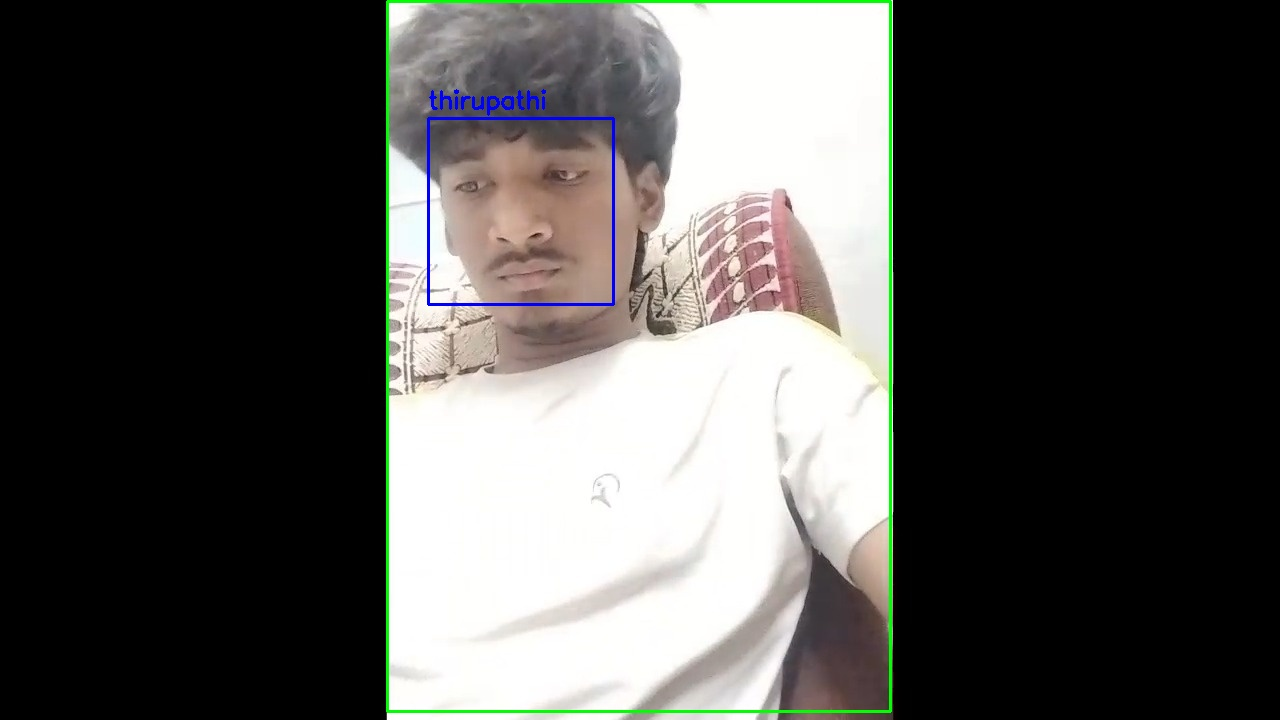

In [13]:
image_path = capture_image(delay=5)

output_path = detect_and_guide(image_path)

display(Image(output_path))